In [1]:
from datetime import datetime
from pathlib import Path

import numpy as np

from e2e.e2esim import run_e2e_prediction
import matplotlib.pyplot as plt

import scienceplots

from e2e.prediction.end_to_end import Plotter

plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"legend.frameon": "False"})
# plt.rcParams.update({"mathtext.default": "regular"})

%load_ext autoreload
%autoreload 2

2023-10-25 10:04:30,034 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmpidc7qyoe
2023-10-25 10:04:30,039 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Writing /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmpidc7qyoe/_remote_module_non_scriptable.py


In [65]:
base = Path("outputs/mc/")
folder = Path("20231012-115741-glorious-elevator-747") 
run_name = "-".join(str(folder).split("-")[-3::])
trues = np.loadtxt(base / folder / "ys.csv", delimiter=",")
preds = np.loadtxt(base / folder/ "mean_predictions.csv", delimiter=",")
uncertainties = np.loadtxt(base / folder / "uncertainties_calib.csv", delimiter=",")
xs = np.loadtxt(base / folder / "xs.csv", delimiter=",")
ys = np.loadtxt(base / folder / "ys.csv", delimiter=",")
ids = np.loadtxt(base / folder / "ids.csv", dtype=str, delimiter=",")


In [66]:
errors = trues - preds


In [67]:
errors.mean(axis=0).shape

(90,)

In [68]:
uncertainties.shape

(56, 90)

2023-10-25 11:17:59,041 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:17:59,045 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:17:59,048 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:17:59,050 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:17:59,052 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:17:59,054 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:17:59,056 - MainThread - INFO - matplotlib.texmanager - No LaT

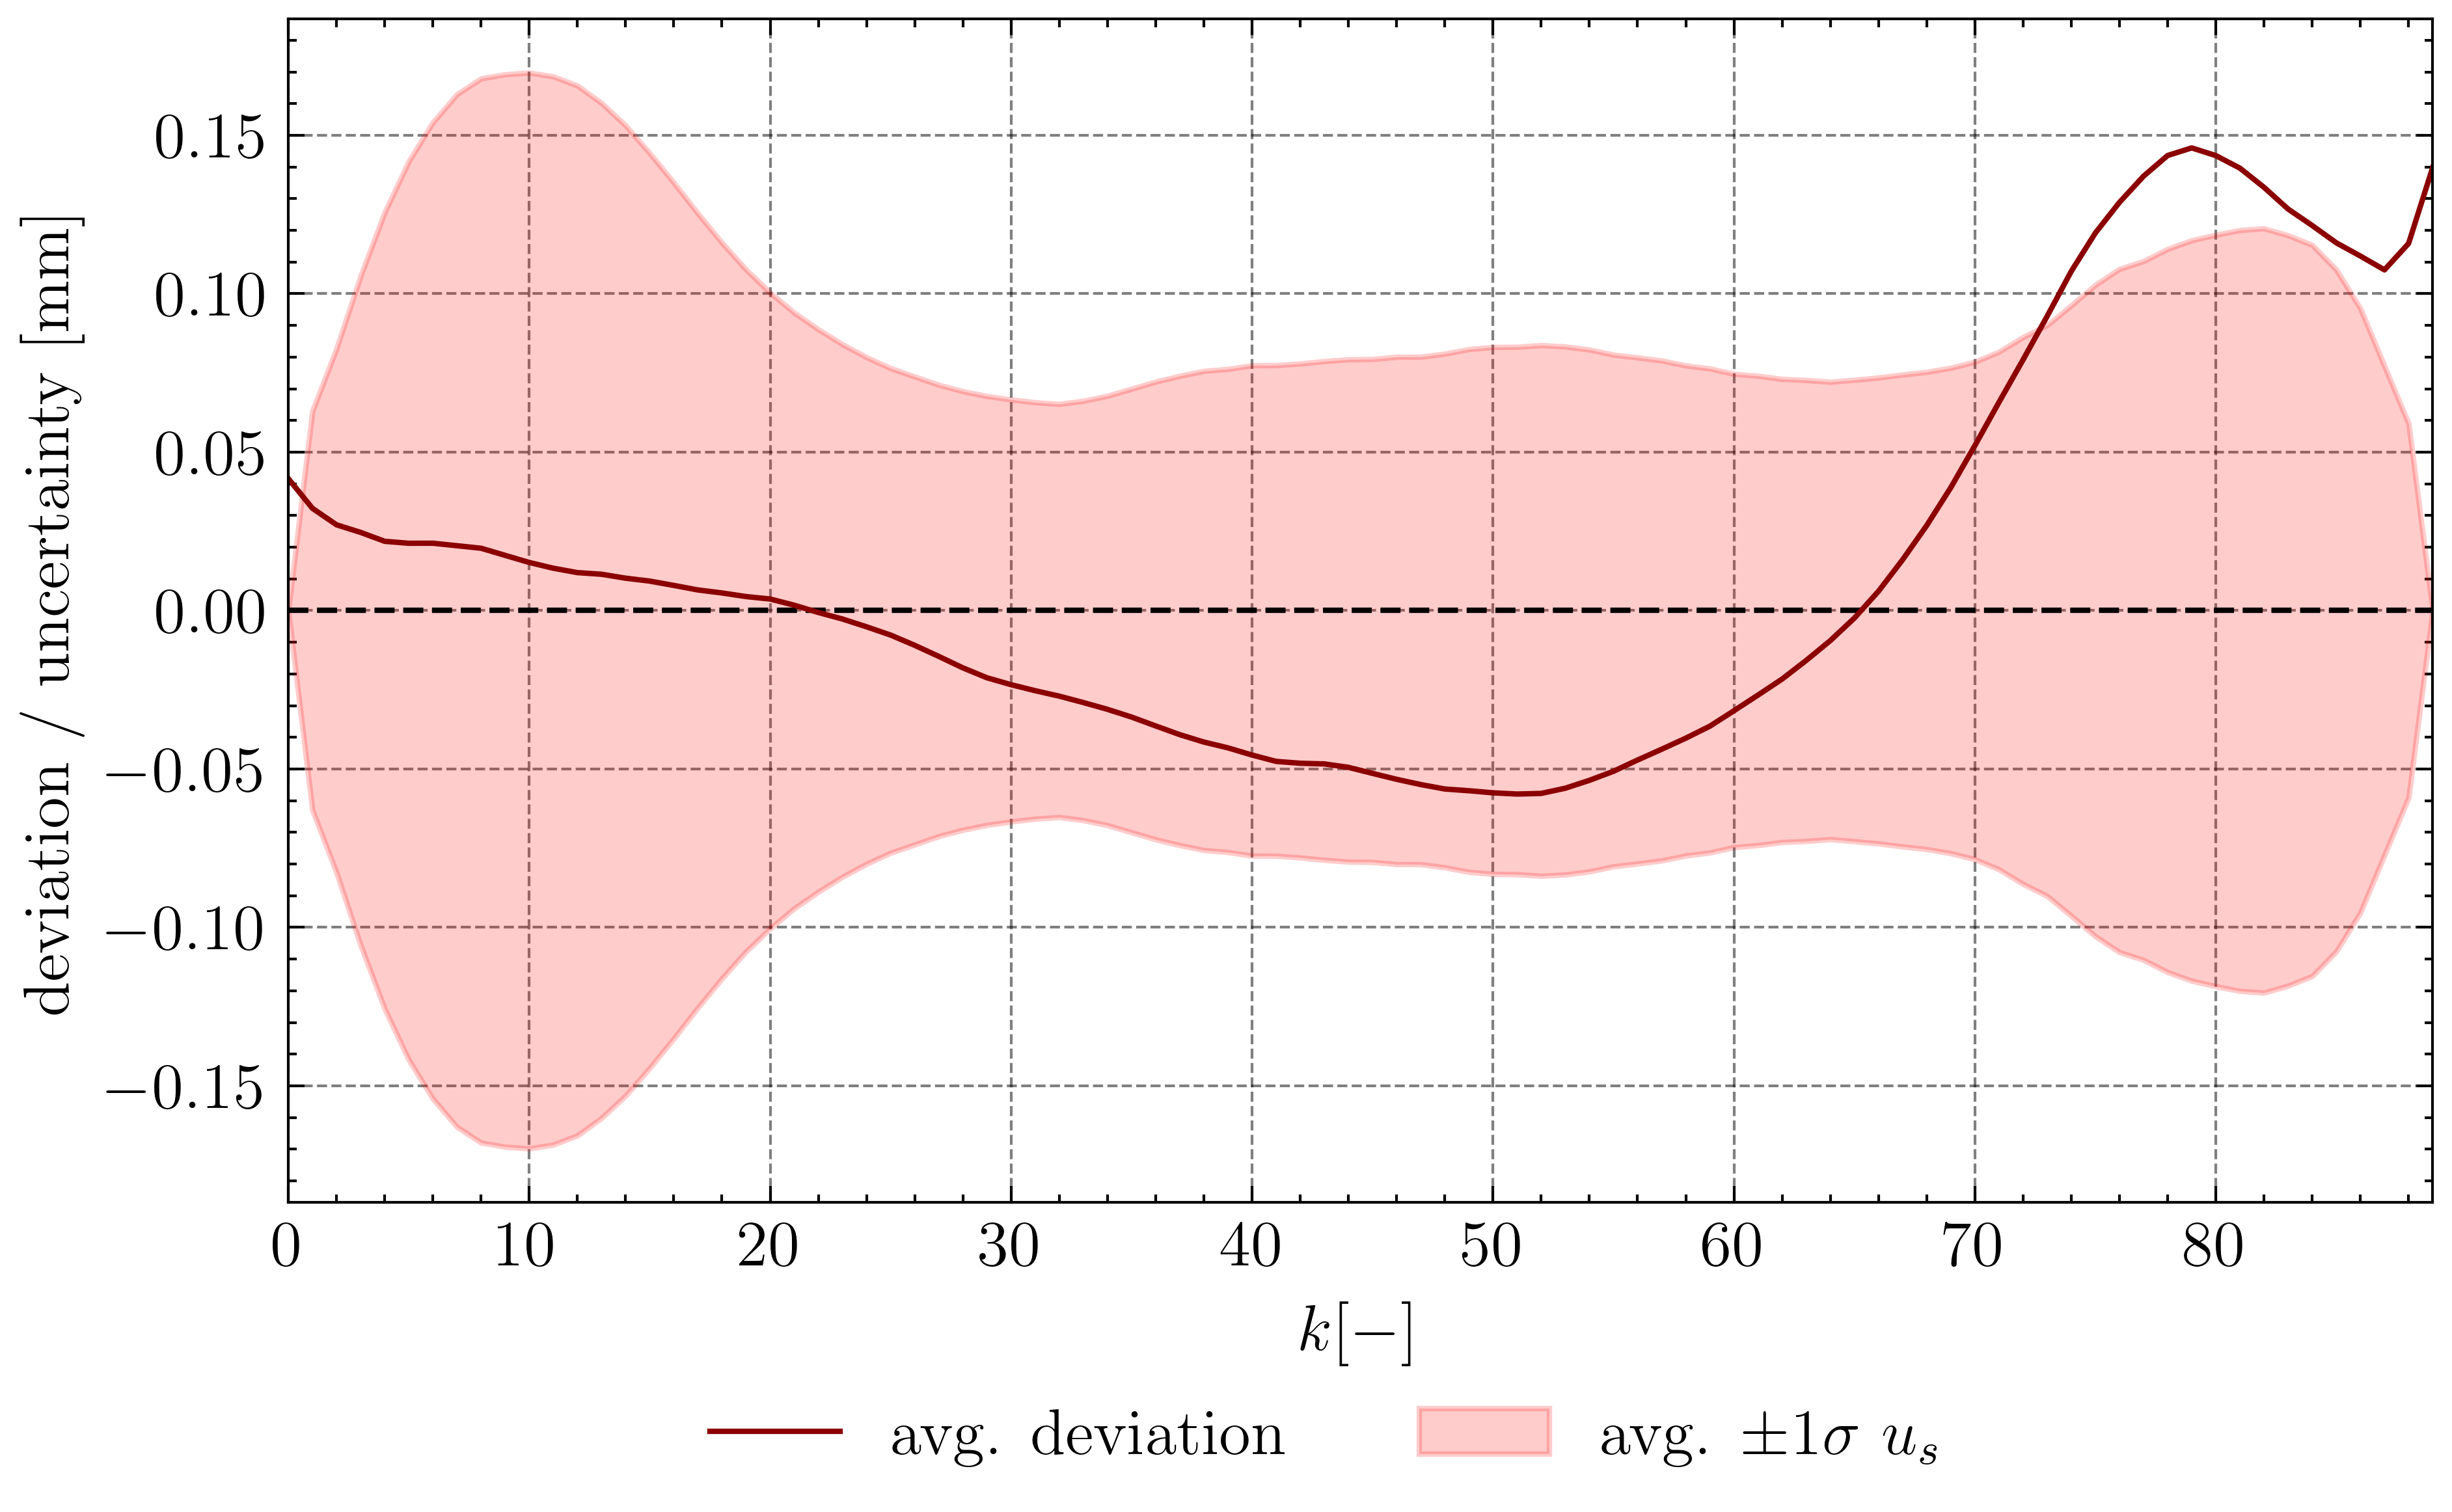

In [80]:
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(18*cm, 10*cm), dpi=600)

start = 0
end = 90

pred_mean = preds.mean(axis=0)
pred_std = uncertainties.std(axis=0)

true_mean = trues.mean(axis=0)
errors = trues - preds
error_mean = errors.mean(axis=0)

reference = true_mean
offset = 1

x = np.arange(start, end)
# ax.plot((true_mean + error_mean)/ true_mean, color="red", alpha=1)
# ax.plot((pred_mean - true_mean) / true_mean, color="blue", alpha=1)
ax.plot(x, np.zeros(end-start), color="black", ls="--", alpha=1)
# ax.plot(x, ((pred_mean/reference) - offset)[start:end], color="red", alpha=1)
ax.plot(x, error_mean[start:end], color="darkred", alpha=1, label="avg. deviation")
# ax.plot(pred_std, color="orange", alpha=0.5)

ax.fill_between(
    x,
    (0 - pred_std)[start:end],
    (0 + pred_std)[start:end],
    color="red",
    alpha=0.2,
    label="avg. $\pm 1 \sigma$ $u_s$ ",
)

ax.set_xlim(0, 89)

ax.set_ylabel("deviation / uncertainty [mm]")
ax.set_xlabel("$k [-]$")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.1), fancybox=False, shadow=False)

# ax.set_yscale('log')
plt.show()


In [81]:
results = Path("/Users/magnus/Desktop/graphics/results")
fig.savefig(results / f"avg-shape-error-uncertainty-{run_name}.pdf", bbox_inches="tight")

2023-10-25 11:19:15,563 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:19:15,628 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:19:15,688 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:19:15,738 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:19:15,812 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:19:15,830 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:19:15,833 - MainThread - INFO - matplotlib.texmanager - No LaT

In [124]:
base = Path("/Users/magnus/repos/waam-footprint/fp/outputs/mc/")
folder = Path("20231005-115213-olive-star-31") 
run_name = "-".join(str(folder).split("-")[-3::])
trues = np.loadtxt(base / folder / "ys.csv", delimiter=",")
preds = np.loadtxt(base / folder/ "mean_predictions.csv", delimiter=",")
uncertainties = np.loadtxt(base / folder / "uncertainties_calib.csv", delimiter=",")
xs = np.loadtxt(base / folder / "xs.csv", delimiter=",")
ids = np.loadtxt(base / folder / "ids.csv", dtype=str, delimiter=",")
errors = trues - preds

2023-10-25 13:55:41,597 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:41,814 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:41,826 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:41,828 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:41,846 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:41,848 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:41,850 - MainThread - INFO - matplotlib.texmanager - No LaT

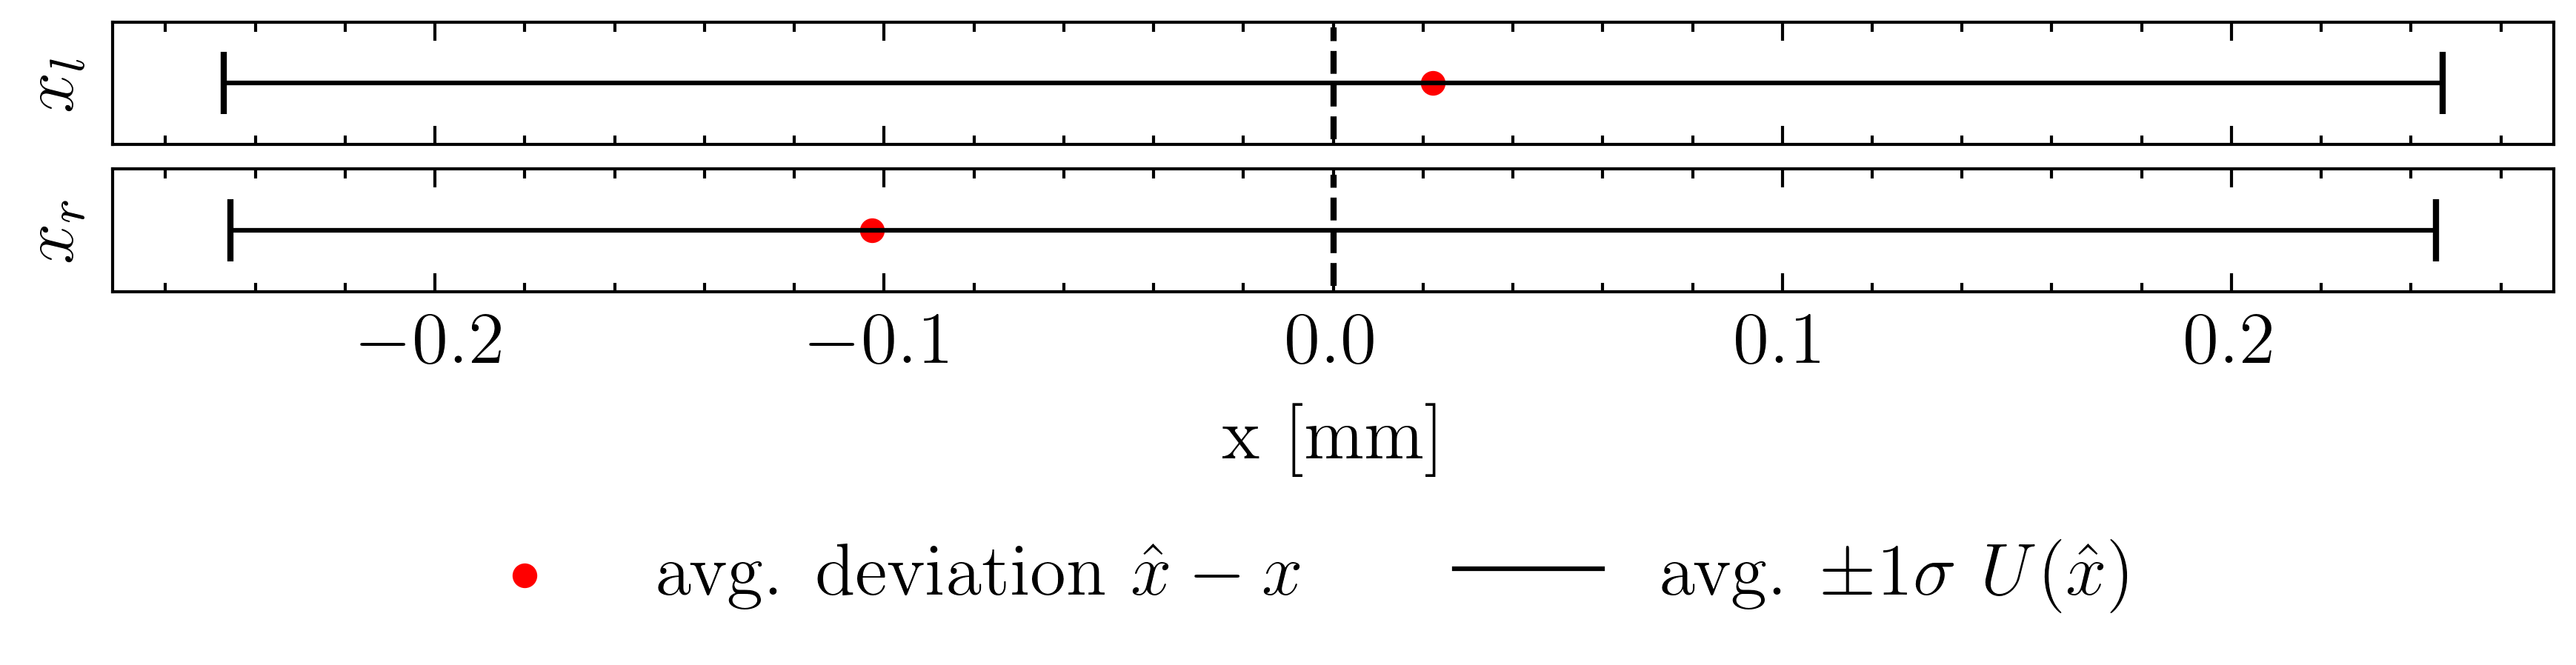

In [196]:
cm = 1 / 2.54
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(18*cm, 2*cm), dpi=600, sharey=True, sharex=True)

mean_left_error = errors[:, 0].mean() * 0.1
mean_right_error = errors[:, 1].mean() * 0.1

mean_left_uncert = uncertainties[:, 0].mean() * 0.1
mean_right_uncert = uncertainties[:, 1].mean() * 0.1

ax1.scatter(mean_left_error, [0] , color="red", marker=".", alpha=1)
ax1.errorbar(0, [0], xerr=mean_left_uncert, color="black", alpha=1, linewidth=0.75, capsize=5)

ax2.scatter(mean_right_error, [0],  color="red", marker=".", alpha=1, label="avg. deviation $\hat{x} - x$")
ax2.errorbar(0, [0], xerr=mean_right_uncert, color="black", alpha=1, linewidth=0.75, capsize=5)

# plot vertical line
ax1.plot([0, 0], [-0.5, 0.5], color="black", ls="--", alpha=1)
ax2.plot([0, 0], [-0.5, 0.5], color="black", ls="--", alpha=1)

ax1.set_yticks([])
ax2.set_yticks([])
ax1.set_ylabel("$x_l$")
ax2.set_ylabel("$x_r$")
ax2.set_xlabel("x [mm]")
ax1.grid(False)
ax2.grid(False)

ax2.plot([], [], color="black", alpha=1, linewidth=0.75, ls="-", label="avg. $\pm 1\sigma$ $U(\hat{x})$")

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -1.0), fancybox=False, shadow=False)



In [197]:
results = Path("/Users/magnus/Desktop/graphics/results")
fig.savefig(results / f"avg-footprint-error-uncertainty-{run_name}.pdf", bbox_inches="tight")

2023-10-25 13:55:49,285 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:49,311 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:49,338 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:49,451 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:49,473 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:49,477 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 13:55:49,510 - MainThread - INFO - matplotlib.texmanager - No LaT

In [9]:
true_fps  = np.array([np.array([np.abs(fp.left_idx - tp), np.abs(fp.right_idx - tp)]) for fp, tp in zip(dataset.true_footprints, dataset.torchpositions)])

NameError: name 'dataset' is not defined

# Uncertainty propagation

In [10]:
from e2e.models.mlp import ResMLP
from e2e.helpers.wandb import download_model
from e2e.models.model import Model
import torch
from e2e.data.resampled import ResampledE2EDataset
from e2e.prediction.end_to_end import DataLoader
from e2e.data.loader import EXPERIMENT as EXP
from e2e.models.modelV2 import ModelV2
from e2e.models.recurrent import LSTM

VERSION = "best"
MAC_DATA_DIR = Path("/Users/magnus/datasets/WAAM/test")

# MLP
MLP_PROJECT_NAME = "waam-e2e-footprint"
MLP_RUN_ID = "y21szkna"

MLP_INPUT_LENGTH = 224
MLP_HIDDEN_LENGTH_FACTOR = 2
MLP_TARGET_LENGTH = 2
MLP_N_LAYERS = 3
MLP_P = 0.5

DEVICE = "cpu"

LSTM_INPUT_LENGTH = 90
LSTM_TARGET_LENGTH = 90
LSTM_P = 0.9

mlp = ResMLP(
    p=MLP_P,
    n_input_features=MLP_INPUT_LENGTH,
    n_hidden=MLP_INPUT_LENGTH * MLP_HIDDEN_LENGTH_FACTOR,
    n_output_features=MLP_TARGET_LENGTH,
    n_layers=MLP_N_LAYERS,
)

lstm = LSTM(
    p=LSTM_P,
    n_input_features=LSTM_INPUT_LENGTH,
    n_output_features=LSTM_TARGET_LENGTH,
    n_hidden=LSTM_TARGET_LENGTH * 3,
    n_layers=10,
)

footprint_path = download_model(project=MLP_PROJECT_NAME, run_id=MLP_RUN_ID, version=VERSION)

footprint_predictor = Model.load_from_checkpoint(
    model=mlp, checkpoint_path=footprint_path, map_location=torch.device(DEVICE)
)

data_loader = DataLoader(MAC_DATA_DIR)
cross_section_samples = data_loader.load_samples([EXP.RANDOM_EX6])
dataset = ResampledE2EDataset(mirror=False, segment_length=MLP_INPUT_LENGTH).create(cross_section_samples)

base = Path("/Users/magnus/repos/waam-e2e/e2e/")
lstm_path = base / Path("./waam-e2e-pre/mbw4tdhh/checkpoints/epoch=199-step=2400.ckpt")
shape_predictor = ModelV2.load_from_checkpoint(
    model=lstm, checkpoint_path=lstm_path, map_location=torch.device(DEVICE)
)
shape_predictor.to("cpu")


wandb:   1 of 1 files downloaded.  
/Users/magnus/miniconda3/envs/waam310/lib/python3.10/site-packages/lightning/pytorch/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.0.3, which is newer than your current Lightning version: v2.0.2
  rank_zero_warn(
100%|██████████| 56/56 [00:05<00:00, 10.48it/s]


ModelV2(
  (model): LSTM(
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc): Linear(in_features=90, out_features=90, bias=True)
    (bn2): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lstm): LSTM(90, 270, num_layers=10, batch_first=True, dropout=0.9)
    (fc2): Linear(in_features=270, out_features=90, bias=True)
    (combine): Linear(in_features=91, out_features=45, bias=True)
    (out): Linear(in_features=45, out_features=3, bias=True)
  )
)

In [110]:
BEAD_NR = 6

target = dataset.targets[BEAD_NR].clone().cpu().numpy()
fp = dataset.true_footprints[BEAD_NR]
tp = dataset.torchpositions[BEAD_NR]

left_fp = int(np.round(fp.left_idx))
right_fp = int(np.round(fp.right_idx))

base = dataset.ground_truth[BEAD_NR][tp-112:tp+112]

2023-10-25 11:42:22,080 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:22,090 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:22,092 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:22,094 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:22,096 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:22,098 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:22,101 - MainThread - INFO - matplotlib.texmanager - No LaT

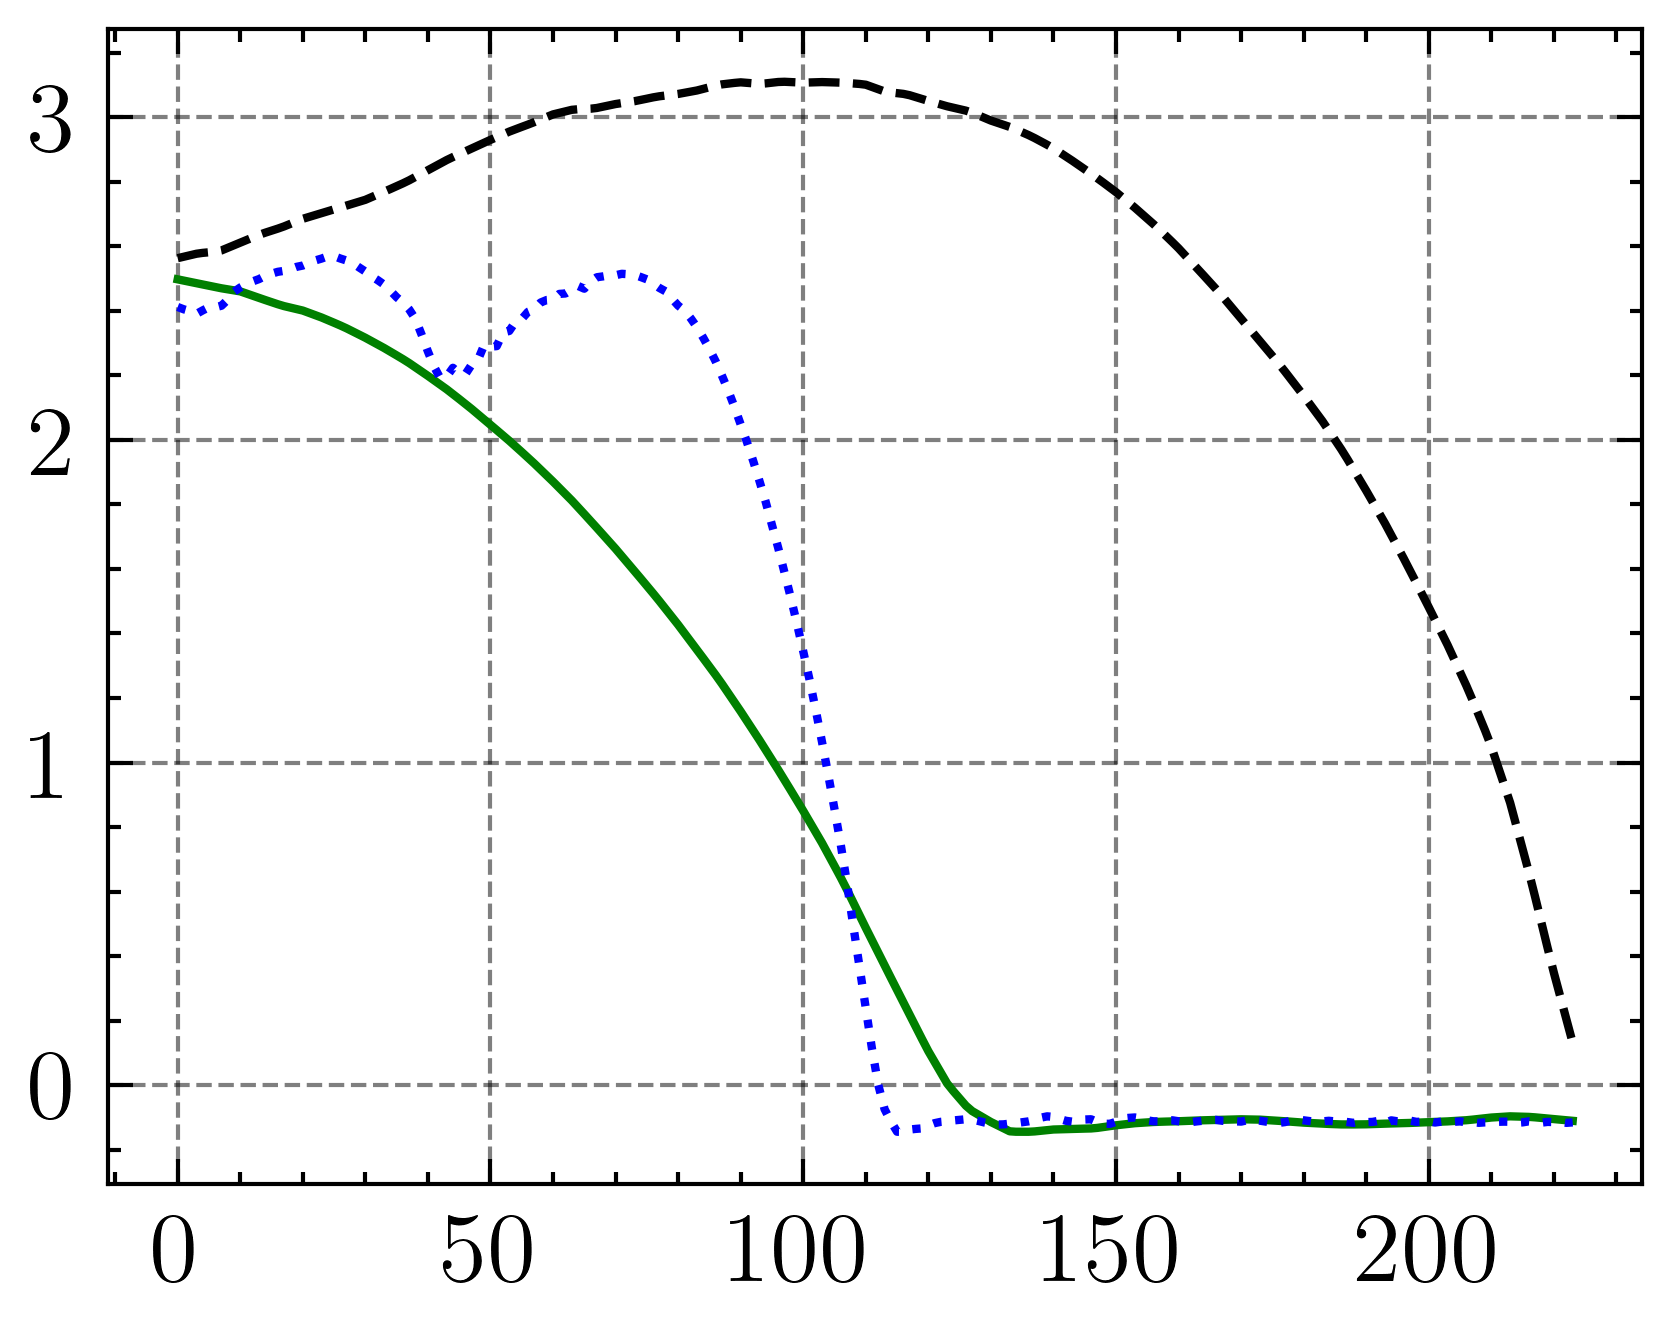

In [111]:
inpt = dataset.inputs[BEAD_NR].clone().cpu().numpy()
plt.plot(inpt, color="green")
plt.plot(target, color="black")
plt.plot(base, color="blue")

In [112]:
N_PREDICTIONS = 10
fp_preds = []

base = torch.tensor(base, dtype=torch.float32).view(-1, 224)
footprint = footprint_predictor.predict_with_uncertainty(base, num_samples=N_PREDICTIONS, reduction="none")
fp_preds.append(footprint.cpu().numpy())

fp_preds = np.array(fp_preds).reshape(-1, 2)

In [113]:
from scipy.interpolate import interp1d

shape_predictions = []
shape_uncertainties = []

curr_input = base.squeeze().cpu().numpy().copy()

for footprint in fp_preds:
    
    footprint = footprint.reshape(-1, 2)
    
    left_fp = int(np.round(footprint[:, 0]))
    right_fp = int(np.round(footprint[:, 1]))
    
    z_offset = curr_input[112]
    curr_input -= z_offset
    
    u = np.zeros_like(curr_input)

    # cut out footprint ~67 points
    segment = curr_input[left_fp:right_fp].copy()
    len_segment = len(segment)
    xs_original = np.arange(0, len_segment) / 10
    f = interp1d(xs_original, segment, kind="linear")
    
    # upsample to 90 points
    xs_90 = np.linspace(0, (len_segment - 1) / 10, 90)
    curr_input_segment = f(xs_90)
    
    # predict -> output is 90 points
    pred, uncertainty = shape_predictor.predict_with_uncertainty(
        torch.tensor(curr_input_segment, dtype=torch.float32).view(-1, 90), num_samples=30,
    )
    pred = pred.detach().cpu().squeeze().numpy()
    
    uncertainty_score = np.sum(uncertainty.detach().cpu().numpy())
    
    # downsample to ~67 points
    f = interp1d(xs_90, pred, kind="linear")
    shape_prediction = f(xs_original)
    shape_prediction += z_offset
    
    fu = interp1d(xs_90, uncertainty.cpu().squeeze().numpy(), kind="linear")
    u[left_fp:right_fp] = fu(xs_original)
    
    # put back into workpiece segment of total 224 points
    pred_out = curr_input.copy()
    pred_out[left_fp:right_fp] = shape_prediction
    
    shape_uncertainties.append(u)
    shape_predictions.append(pred_out)

shape_predictions = np.array(shape_predictions)    
shape_uncertainties = np.array(shape_uncertainties)

In [114]:
fp_left, fp_right  = tp-fp.left_idx, fp.right_idx-tp

left = 112 - fp_left
right = 112 + fp_right
xs_224 = np.arange(0, 224) * 0.1
true_next =  curr_input.copy()
ft = interp1d(xs_224, target, kind="linear")
x_target = np.linspace(0, (224 - 1) / 10, right-left)
true_next[left:right] = ft(x_target)

Text(0, 0.5, '$z$ [mm]')

2023-10-25 11:42:24,473 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:24,481 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:24,484 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:24,486 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:24,488 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:24,490 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 11:42:24,491 - MainThread - INFO - matplotlib.texmanager - No LaT

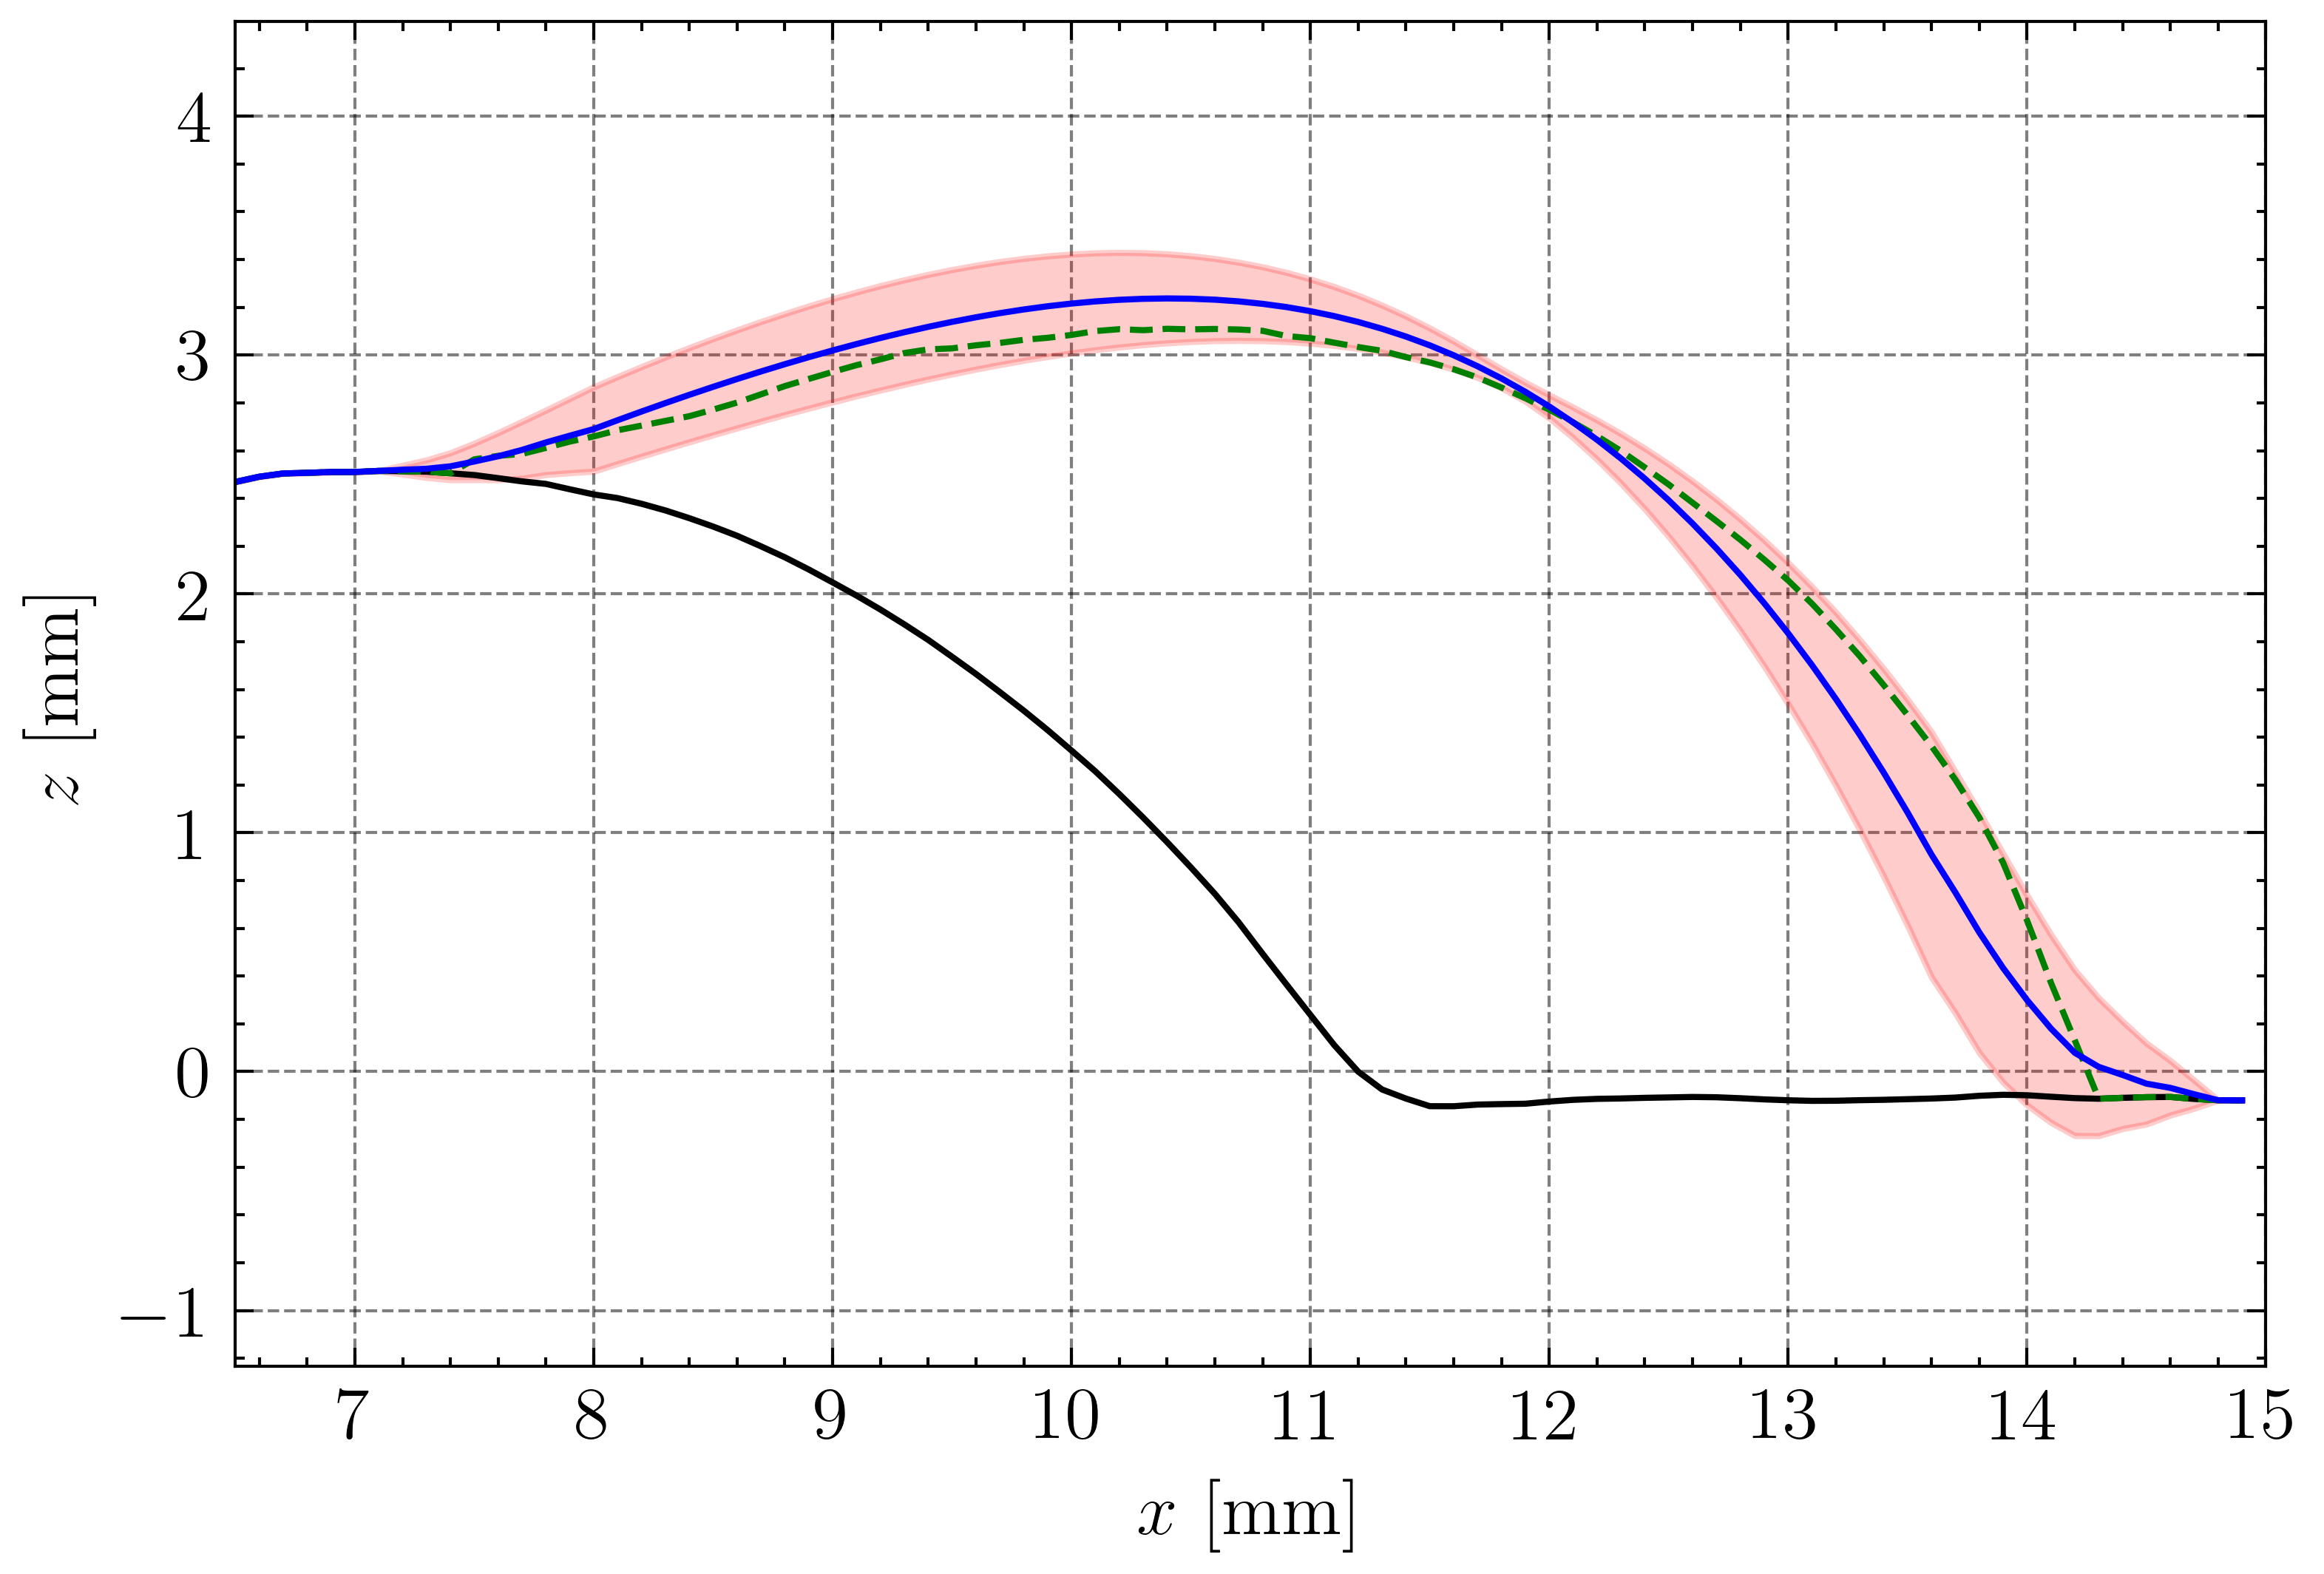

In [115]:
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(15*cm, 10*cm), dpi=600)

start = 65
end = 150

x = (np.arange(0, 224) * 0.1)[start:end]
inpt = base.squeeze()
ax.plot(x, inpt[start:end], color="black", ls="-",alpha=1, label="input $W_i$")
ax.plot(x, true_next[start:end], color="green", ls="--",alpha=1, label="target (measured) $W_{i+1}$")

# for shape in shape_predictions:
#     ax.plot(x, shape[start:end], color="blue", ls="-",alpha=0.3)

ax.plot(x, shape_predictions.mean(axis=0)[start:end], color="blue", ls="-",alpha=1, label="prediction (mean), $\hat{F}$ and $\hat{S}$")
ax.fill_between(
    x,
    (shape_predictions.mean(axis=0) - shape_predictions.std(axis=0))[start:end],
    (shape_predictions.mean(axis=0) + shape_predictions.std(axis=0))[start:end],
    color="red", alpha=0.2, label="uncertainty $U(\hat{S}(x))$",)

ax.axis("equal")
ax.set_xlim(start/10, end/10)
ax.set_xlabel("$x$ [mm]")
ax.set_ylabel("$z$ [mm]")

# add legend below plot
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.2), fancybox=False, shadow=False)
# no frame on legend


In [116]:
shape_predictions.mean(axis=0).shape

(224,)

In [117]:
from scipy.spatial.distance import cdist

modhaussdorff = []

x = np.arange(0, 224 / 10, 0.1)[70:150]

xa = np.array(list(zip(x, true_next[70:150])))
xb = np.array(list(zip(x, shape_predictions.mean(axis=0)[70:150])))

dist = cdist(xa, xb)
mins = np.min(dist, axis=1)

modhaussdorff.append((np.median(mins)))
modhaussdorff[0] * 1000

92.07284450531006

In [90]:
uu_sf = shape_predictions.std(axis=0).sum() * 0.1

1.4924278259277344

In [50]:

results = Path("/Users/magnus/Desktop/graphics/results")
uncert_prop = Path("uncert-prop")
fig.savefig(results / uncert_prop / f"E5-{BEAD_NR}.pdf", bbox_inches="tight")

2023-10-25 10:20:24,730 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:20:24,733 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:20:24,738 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:20:24,740 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:20:24,742 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:20:24,744 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:20:24,747 - MainThread - INFO - matplotlib.texmanager - No LaT

2023-10-25 10:39:13,458 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:39:13,464 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:39:13,478 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:39:13,481 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:39:13,482 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:39:13,484 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-25 10:39:13,485 - MainThread - INFO - matplotlib.texmanager - No LaT

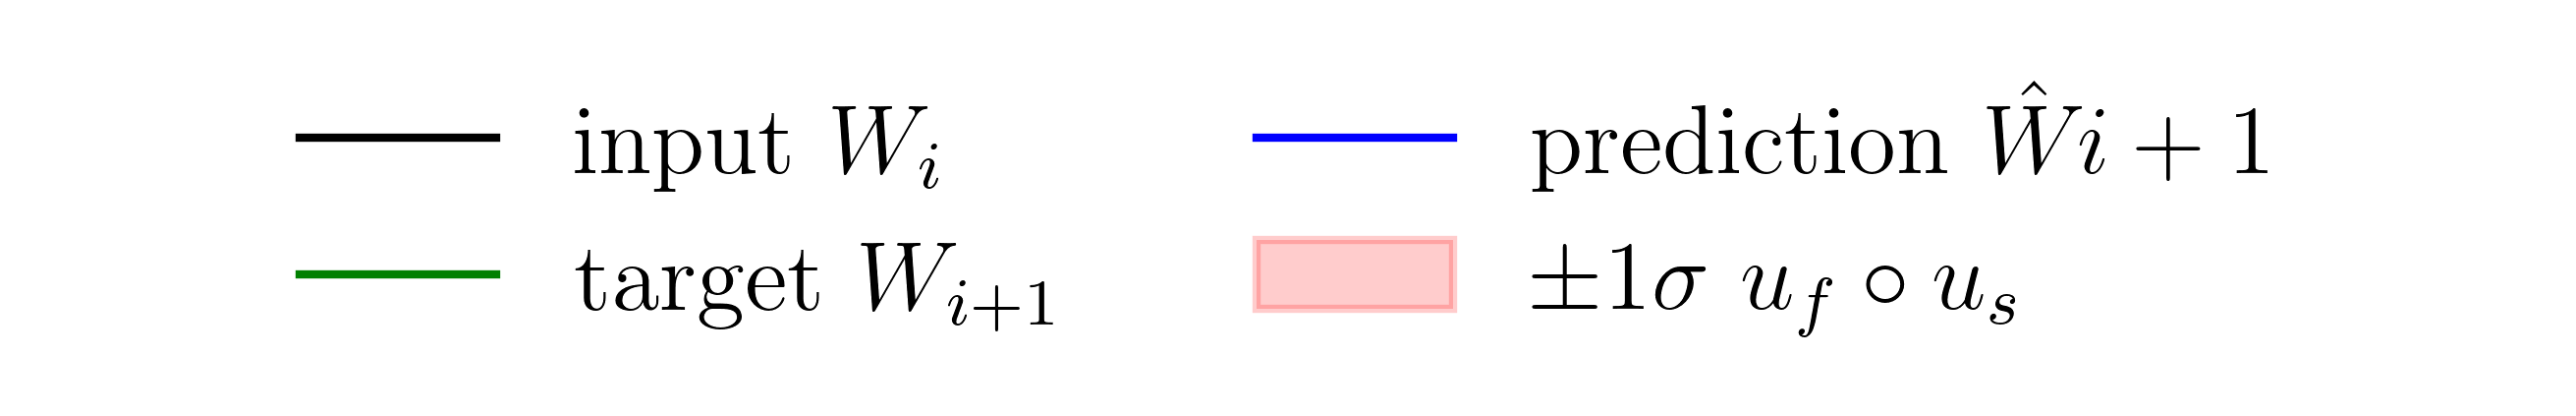

In [63]:
cm= 1/2.54
legend_fig, legend_ax = plt.subplots(figsize=(14*cm, 2*cm))
# legend_ax = legend_fig.add_subplot(111)
# legend_ax.axis('off')
legend_ax.plot([], color="black", ls="-", label="input $W_i$")
legend_ax.plot([], color="green", ls="-", label="target $W_{i+1}$")
legend_ax.plot([], color="blue", ls="-", label="prediction $\hat{W}_{}i+1$")
legend_ax.fill_between([], [], [], color="red", alpha=0.2, label="$\pm 1 \sigma$ $u_f \circ u_s$ ")

legend_ax.axis('off')
legend_ax.legend(loc='center', ncol=2)
legend_ax.get_legend().get_frame().set_linewidth(0.0)

# save fig
results = Path("/Users/magnus/Desktop/graphics/results")
uncert_prop = Path("uncert-prop")
legend_fig.savefig(results / uncert_prop / f"uncert-prop-legend.pdf", bbox_inches="tight")